In [1]:
import sys, pathlib
CWD = pathlib.Path.cwd().resolve()
ROOT = CWD if (CWD / 'src').exists() else CWD.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

IMAGE_PATH    = ROOT / 'data' / 'sample_image.jpg'
MEASURES_PATH = ROOT / 'data' / 'sample_measures.json'
HORIZON_CACHE = ROOT / 'data' / 'horizon_profile.json'

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Nouvelle architecture ─────────────────────────────────────────────────────
from src.solar_model import SolarModel
from src.names import (
    SolarModelOptions, PyranoInfo, PyranoMeasure,
    RealPyrano, VirtualPyrano,
)
from src.projection import project_on_target, project_on_targets
from src.vision import compute_horizon_from_image, SINGLE_HALF_RIGHT
from src.constants.values import SOLVER_CFG

print('Imports OK')
print(f'Solveur 1D : {SOLVER_CFG.kd_steps} pas  [{SOLVER_CFG.kd_min}, {SOLVER_CFG.kd_max}]')
print(f'Solveur 3D : f1 [{SOLVER_CFG.f1_min}, {SOLVER_CFG.f1_max}]  '
      f'f2 [{SOLVER_CFG.f2_min}, {SOLVER_CFG.f2_max}]')


Imports OK
Solveur 1D : 100 pas  [0.0001, 1.0]
Solveur 3D : f1 [0.0, 1.5]  f2 [-1.8, 0.5]


In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from src.solar_model import SolarModel
from src.names import (
    SolarModelOptions,
    PyranoInfo, PyranoMeasure,
    RealPyrano, VirtualPyrano,
)
from src.vision import compute_horizon_from_image, SINGLE_HALF_RIGHT
from src.constants.values import KD_GRID_MIN, KD_GRID_MAX, KD_GRID_STEPS

print('Imports OK')

Imports OK


## 1. Extraction du profil d'horizon depuis l'image fisheye

Si `01_test_vision.ipynb` a déjà été exécuté, le cache `horizon_profile.json`
est utilisé directement pour eviter de recharger MiDaS. Sinon, le pipeline
vision complet est lance ici (environ 30s au premier appel).

Horizons chargés depuis le cache (Toit et Façade).


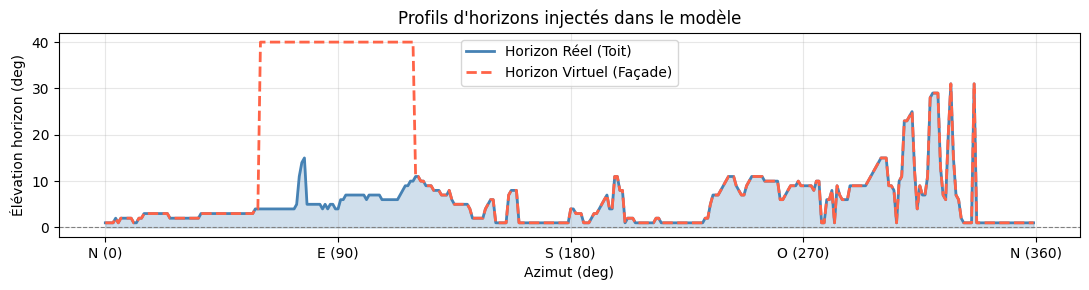

In [3]:
if HORIZON_CACHE.exists():
    with open(HORIZON_CACHE) as f:
        horizon_data = json.load(f)
    # Chargement dynamique des deux profils
    horizon_real = np.array(horizon_data.get('horizon_real', np.zeros(360)))
    horizon_virtual = np.array(horizon_data.get('horizon_virtual_1', np.zeros(360)))
    print(f"Horizons chargés depuis le cache (Toit et Façade).")
elif IMAGE_PATH.exists():
    print("Calcul du profil d'horizon via MiDaS...")
    horizon_real = compute_horizon_from_image(
        image_path = str(IMAGE_PATH), fov_deg = 180, single_half = SINGLE_HALF_RIGHT,
        azimuth_deg = 0.0, inclination_deg = 0.0
    )
    horizon_virtual = horizon_real.copy() # Par défaut, on met le même
    with open(HORIZON_CACHE, 'w') as f:
        json.dump({'horizon_real': horizon_real.tolist(), 'horizon_virtual_1': horizon_virtual.tolist()}, f)
else:
    print("ATTENTION : utilisation d'un horizon plat.")
    horizon_real = np.zeros(360)
    horizon_virtual = np.zeros(360)

# --- Affichage comparatif ---
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(np.arange(360), np.rad2deg(horizon_real), color='steelblue', linewidth=2, label='Horizon Réel (Toit)')
ax.plot(np.arange(360), np.rad2deg(horizon_virtual), color='tomato', linestyle='--', linewidth=2, label='Horizon Virtuel (Façade)')
ax.fill_between(np.arange(360), np.rad2deg(horizon_real), alpha=0.25, color='steelblue')

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_xlabel('Azimut (deg)')
ax.set_ylabel('Élévation horizon (deg)')
ax.set_title("Profils d'horizons injectés dans le modèle")
ax.set_xticks([0, 90, 180, 270, 360])
ax.set_xticklabels(['N (0)', 'E (90)', 'S (180)', 'O (270)', 'N (360)'])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Chargement des mesures

In [4]:
with open(MEASURES_PATH) as f:
    raw = json.load(f)

meta         = raw['meta']
measurements = raw['measurements']

# Extraction des données communes
timestamps   = np.array([m['time'] for m in measurements])
origin_vals  = np.array([m['pyrano_origin_wm2'] for m in measurements], dtype=float)
dest_configs = measurements[0]['pyrano_dest']

print(f"Site      : {meta['site']}")
print(f"Periode   : {timestamps[0]}  ->  {timestamps[-1]}")
print(f"GHI range : {origin_vals.min():.1f} - {origin_vals.max():.1f} W/m²")



Site      : Paris, toit Haussmannien
Periode   : 2024-06-21 07:00:00.000  ->  2024-06-21 16:00:00.000
GHI range : 150.0 - 900.0 W/m²


## 3. Pipeline 1D — fit_parameters() par instant

`SolarModel.fit_parameters()` retourne maintenant un **`AtmosphericState`** —
il ne fait plus de projection. La projection est déléguée à `project_on_target()`.

```
model.fit_parameters()  →  AtmosphericState(kd, BHI, DHI, gamma_s, ...)
project_on_target(cible, atmosphere)  →  DataFrame(GTI, DTI, BTI, RTI)
```


In [ ]:
# Options globales (identiques pour toutes les mesures)
options = SolarModelOptions(
    latitude        = meta['latitude'],
    longitude       = meta['longitude'],
    elevation_meter = meta['elevation_meter'],
    albedo          = 0.2,
    use_riso        = False,
)

# ── Définition de la cible (façade Sud 90°) ───────────────────────────────────
dest_configs = measurements[0]['pyrano_dest']
target_facade = VirtualPyrano(
    info=PyranoInfo(
        azimuth_deg     = float(dest_configs[0]['azimuth_deg']),
        inclination_deg = float(dest_configs[0]['inclination_deg']),
        horizon_rad     = horizon_virtual,
    )
)

print(f"Site : {meta['site']}")
print(f"Cible : Az={target_facade.info.azimuth_deg}°  Inc={target_facade.info.inclination_deg}°")
print(f"\nPipeline 1D — {len(measurements)} instants...\n")

atm_1d_list   = []   # liste des AtmosphericState
kd_history    = []
time_history  = []
results_1d    = []

for m in measurements:
    t_str = m['time']
    time_history.append(t_str.split(' ')[1][:5])

    # ── Construire le modèle pour cet instant ─────────────────────────────────
    model = SolarModel(options)

    model.set_origin(RealPyrano(
        info     = PyranoInfo(azimuth_deg=0.0, inclination_deg=0.0,
                              horizon_rad=horizon_real),
        measures = PyranoMeasure(
            timestamps      = np.array([t_str]),
            irradiation_Wm2 = np.array([m['pyrano_origin_wm2']], dtype=float),
        )
    ))

    for fit in m['pyrano_fit']:
        model.add_fit(RealPyrano(
            info     = PyranoInfo(
                azimuth_deg     = float(fit['azimuth_deg']),
                inclination_deg = float(fit['inclination_deg']),
                horizon_rad     = horizon_real,
            ),
            measures = PyranoMeasure(
                timestamps      = np.array([t_str]),
                irradiation_Wm2 = np.array([fit['value_wm2']], dtype=float),
            )
        ))

    # ── Pipeline 1D : retourne AtmosphericState ───────────────────────────────
    atm = model.fit_parameters()
    atm_1d_list.append(atm)
    kd_history.append(atm.kd)

    # ── Projection sur la cible (séparée du fit) ──────────────────────────────
    df_proj = project_on_target(target_facade, atm)
    results_1d.append(df_proj)

df_final_1d = pd.concat(results_1d, ignore_index=True)
print(f"\nPipeline 1D terminé — kd moyen : {np.mean(kd_history):.3f}")
print(f"Colonnes résultat : {list(df_final_1d.columns)}")


Site : Paris, toit Haussmannien
Cible : Az=180.0°  Inc=90.0°

Pipeline 1D — 10 instants...

[solver 1D] kd = 0.5253  (index médian : 52)
[solver 1D] kd = 0.4647  (index médian : 46)
[solver 1D] kd = 0.4546  (index médian : 45)
[solver 1D] kd = 0.6667  (index médian : 66)
[solver 1D] kd = 0.0001  (index médian : 0)
[solver 1D] kd = 0.0001  (index médian : 0)
[solver 1D] kd = 0.1112  (index médian : 11)
[solver 1D] kd = 0.6667  (index médian : 66)
[solver 1D] kd = 0.5051  (index médian : 50)
[solver 1D] kd = 0.8081  (index médian : 80)

Pipeline 1D terminé — kd moyen : 0.420
Colonnes résultat : ['time', 'GTI', 'DTI', 'BTI', 'RTI', 'kd', 'f1', 'f2', 'pipeline']


## 4. Évolution du kd (Pipeline 1D)


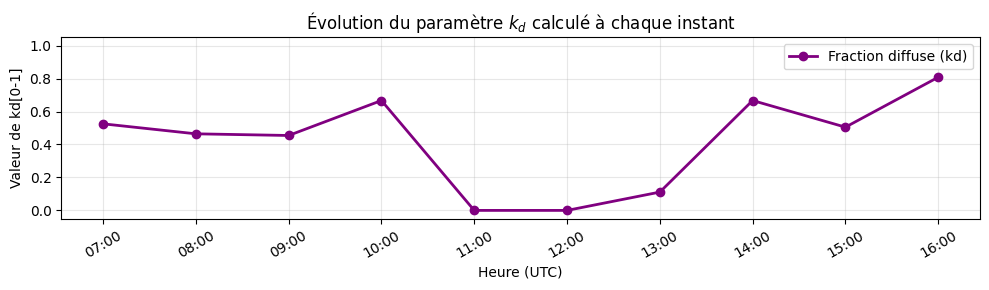

Moyenne kd sur la période : 0.420


In [7]:
x = np.arange(len(time_history))

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(x, kd_history, marker='o', color='purple', linewidth=2, label='Fraction diffuse (kd)')
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)')
ax.set_ylabel('Valeur de kd[0-1]')
ax.set_title('Évolution du paramètre $k_d$ calculé à chaque instant')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Moyenne kd sur la période : {np.mean(kd_history):.3f}")

## 5. Pipeline 3D — fit_parameters_3d() par instant

`fit_parameters_3d()` retourne aussi un `AtmosphericState`, avec en plus
`f1` et `f2` optimisés. La même fonction `project_on_target()` détecte
automatiquement le pipeline et applique le bon moteur de projection.

```
atm_3d = model.fit_parameters_3d(kd_init=atm_1d.kd)
df_3d  = project_on_target(target_facade, atm_3d)
```

`kd_1D` est passé comme point de départ pour accélérer la convergence L-BFGS-B.


In [9]:
# ── Pipeline 3D : réutilise les modèles déjà préparés ────────────────────────
# Les AtmosphericState 1D fournissent le kd_init pour accélérer L-BFGS-B
print(f"Pipeline 3D — {len(measurements)} instants...\n")

atm_3d_list  = []
kd_3d_history  = []
f1_3d_history  = []
f2_3d_history  = []
err_3d_history = []
results_3d     = []

for idx, (m, atm_1d) in enumerate(zip(measurements, atm_1d_list)):
    t_str = m['time']

    # Reconstruire le modèle (même configuration)
    model_3d = SolarModel(options)
    model_3d.set_origin(RealPyrano(
        info     = PyranoInfo(azimuth_deg=0.0, inclination_deg=0.0,
                              horizon_rad=horizon_real),
        measures = PyranoMeasure(
            timestamps      = np.array([t_str]),
            irradiation_Wm2 = np.array([m['pyrano_origin_wm2']], dtype=float),
        )
    ))
    for fit in m['pyrano_fit']:
        model_3d.add_fit(RealPyrano(
            info     = PyranoInfo(
                azimuth_deg     = float(fit['azimuth_deg']),
                inclination_deg = float(fit['inclination_deg']),
                horizon_rad     = horizon_real,
            ),
            measures = PyranoMeasure(
                timestamps      = np.array([t_str]),
                irradiation_Wm2 = np.array([fit['value_wm2']], dtype=float),
            )
        ))

    # Pipeline 3D — kd_init = résultat du pipeline 1D pour cet instant
    atm_3d = model_3d.fit_parameters_3d(kd_init=atm_1d.kd, n_restarts=6)
    atm_3d_list.append(atm_3d)
    kd_3d_history.append(atm_3d.kd)
    f1_3d_history.append(atm_3d.f1)
    f2_3d_history.append(atm_3d.f2)
    err_3d_history.append(atm_3d.fit_error)

    # Projection — même appel, pipeline="3D" détecté automatiquement
    df_proj_3d = project_on_target(target_facade, atm_3d)
    results_3d.append(df_proj_3d)

df_final_3d = pd.concat(results_3d, ignore_index=True)
print(f"\nPipeline 3D terminé — kd moyen : {np.mean(kd_3d_history):.3f}")
print(f"  f1 moyen : {np.mean(f1_3d_history):.3f}   f2 moyen : {np.mean(f2_3d_history):.3f}")


Pipeline 3D — 10 instants...

[solver 3D] kd=0.4646  f1=0.2134  f2=0.0229  err=20.96 W/m²
[solver 3D] kd=0.2809  f1=0.1248  f2=0.2697  err=54.50 W/m²
[solver 3D] kd=0.3324  f1=0.2835  f2=0.1090  err=36.75 W/m²
[solver 3D] kd=0.5541  f1=0.2857  f2=-0.2338  err=50.70 W/m²
[solver 3D] kd=0.1395  f1=0.2935  f2=-0.7158  err=70.63 W/m²
[solver 3D] kd=0.3311  f1=0.7697  f2=-0.3420  err=47.80 W/m²
[solver 3D] kd=0.3168  f1=0.3188  f2=-0.2493  err=130.44 W/m²
[solver 3D] kd=0.5104  f1=0.1650  f2=-0.2706  err=58.23 W/m²
[solver 3D] kd=0.4143  f1=0.3562  f2=-0.0888  err=16.57 W/m²
[solver 3D] kd=0.8095  f1=0.4724  f2=-0.2279  err=9.07 W/m²

Pipeline 3D terminé — kd moyen : 0.415
  f1 moyen : 0.328   f2 moyen : -0.173


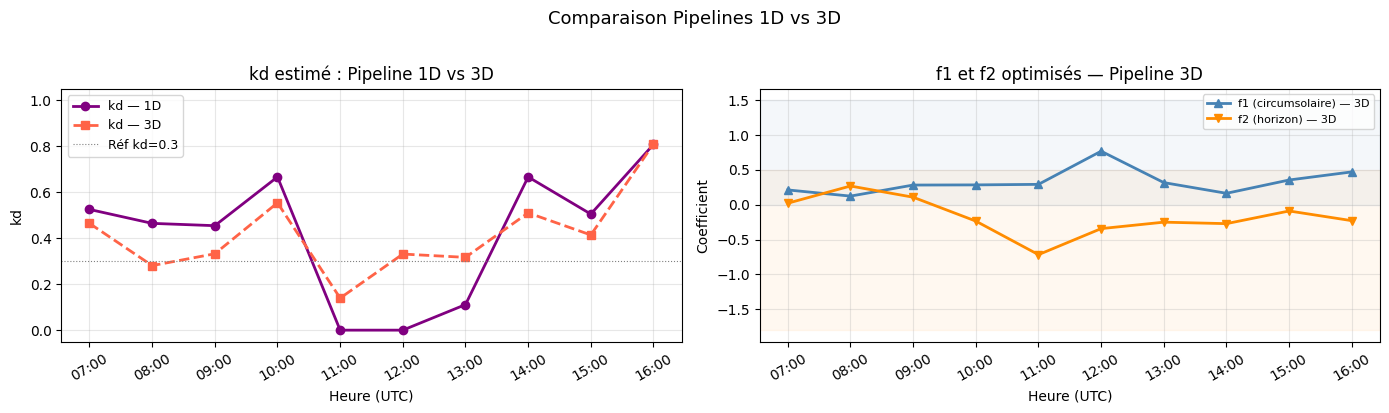

In [10]:
# ── Comparaison kd  +  f1/f2 du pipeline 3D ─────────────────────────────────
x = np.arange(len(time_history))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(x, kd_history,    marker='o', color='purple', lw=2, label='kd — 1D')
ax.plot(x, kd_3d_history, marker='s', color='tomato',  lw=2, linestyle='--', label='kd — 3D')
ax.axhline(0.3, color='gray', linestyle=':', lw=0.8, label='Réf kd=0.3')
ax.set_ylim(-0.05, 1.05)
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)'); ax.set_ylabel('kd')
ax.set_title('kd estimé : Pipeline 1D vs 3D')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, f1_3d_history, marker='^', color='steelblue',  lw=2, label='f1 (circumsolaire) — 3D')
ax.plot(x, f2_3d_history, marker='v', color='darkorange', lw=2, label='f2 (horizon) — 3D')
ax.axhspan(SOLVER_CFG.f1_min, SOLVER_CFG.f1_max, alpha=0.06, color='steelblue')
ax.axhspan(SOLVER_CFG.f2_min, SOLVER_CFG.f2_max, alpha=0.06, color='darkorange')
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)'); ax.set_ylabel('Coefficient')
ax.set_title('f1 et f2 optimisés — Pipeline 3D')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('Comparaison Pipelines 1D vs 3D', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


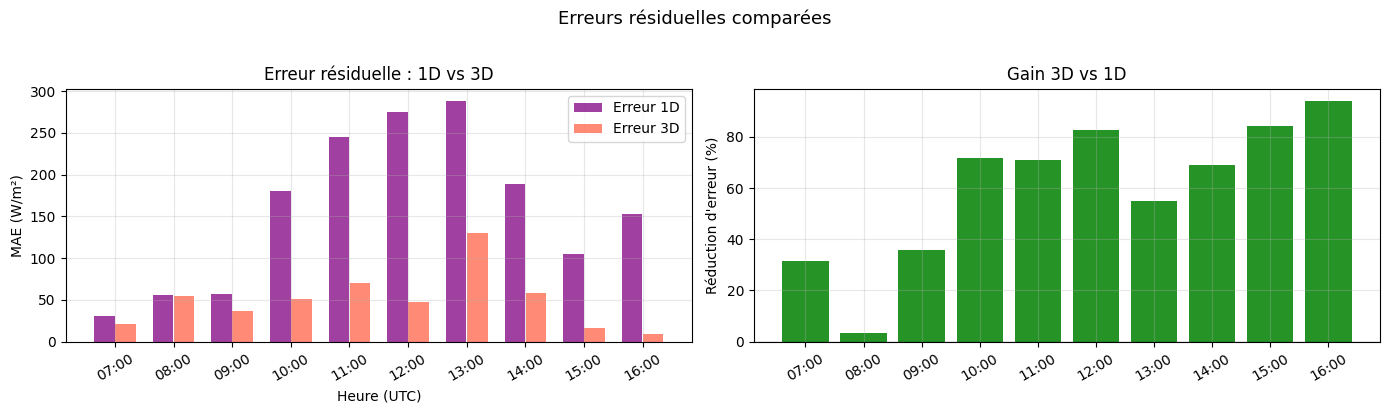

Erreur 1D  moyenne : 157.82 W/m²
Erreur 3D  moyenne : 49.56 W/m²
Gain moyen         : 59.9%


In [11]:
# ── Erreurs résiduelles 1D vs 3D ─────────────────────────────────────────────
# Pipeline 1D : erreur au kd optimal dans la matrice Grid Search
# Pipeline 3D : erreur résiduelle L-BFGS-B stockée dans atm.fit_error
from src.solver import fit_kd, get_errors_kd
from src.constants.values import SOLVER_CFG

err_1d_history = []
for atm_1d, m in zip(atm_1d_list, measurements):
    # Recalcul de l'erreur 1D depuis l'AtmosphericState
    # (on reconstruit la grille et on prend l'erreur au kd optimal)
    kd_list = np.linspace(SOLVER_CFG.kd_min, SOLVER_CFG.kd_max, SOLVER_CFG.kd_steps)
    kd_idx  = int(np.argmin(np.abs(kd_list - atm_1d.kd)))
    # Erreur = somme |GTIsim - GTIreal| pour tous les fits à ce kd
    total = 0.0
    from src.utils import project_gti
    for fit in m['pyrano_fit']:
        gti_sim, *_ = project_gti(
            alpha     = np.deg2rad(float(fit['azimuth_deg'])),
            beta      = np.deg2rad(float(fit['inclination_deg'])),
            BHI       = atm_1d.BHI, DHI=atm_1d.DHI,
            gamma_s   = atm_1d.gamma_s, alpha_s=atm_1d.alpha_s, TOANI=atm_1d.TOANI,
            elevation = atm_1d.options.elevation_meter,
            albedo    = atm_1d.options.albedo,
            use_riso  = False, Riso=None, horizon=None,
        )
        total += float(np.sum(np.abs(gti_sim - np.array([fit['value_wm2']]))))
    err_1d_history.append(total)

x    = np.arange(len(time_history))
gain = [(e1 - e3) / max(e1, 1e-3) * 100
        for e1, e3 in zip(err_1d_history, err_3d_history)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.bar(x - 0.18, err_1d_history, width=0.35, color='purple', alpha=0.75, label='Erreur 1D')
ax.bar(x + 0.18, err_3d_history, width=0.35, color='tomato',  alpha=0.75, label='Erreur 3D')
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_xlabel('Heure (UTC)'); ax.set_ylabel('MAE (W/m²)')
ax.set_title('Erreur résiduelle : 1D vs 3D')
ax.legend(); ax.grid(True, alpha=0.3)

colors_bar = ['green' if g >= 0 else 'red' for g in gain]
ax = axes[1]
ax.bar(x, gain, color=colors_bar, alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_ylabel("Réduction d'erreur (%)"); ax.set_title("Gain 3D vs 1D")
ax.grid(True, alpha=0.3)

plt.suptitle("Erreurs résiduelles comparées", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

print(f"Erreur 1D  moyenne : {np.mean(err_1d_history):.2f} W/m²")
print(f"Erreur 3D  moyenne : {np.mean(err_3d_history):.2f} W/m²")
print(f"Gain moyen         : {np.mean(gain):.1f}%")


In [12]:
# ── Tableau comparatif ────────────────────────────────────────────────────────
df_compare = pd.DataFrame({
    'Heure'   : time_history,
    'kd_1D'   : [round(v, 4) for v in kd_history],
    'kd_3D'   : [round(v, 4) for v in kd_3d_history],
    'Δkd'     : [round(v3 - v1, 4) for v1, v3 in zip(kd_history, kd_3d_history)],
    'f1_3D'   : [round(v, 4) for v in f1_3d_history],
    'f2_3D'   : [round(v, 4) for v in f2_3d_history],
    'Err_1D'  : [round(v, 2) for v in err_1d_history],
    'Err_3D'  : [round(v, 2) for v in err_3d_history],
    'Gain_%'  : [round(g, 1) for g in gain],
})
display(df_compare)
df_compare.to_csv(ROOT / 'data' / 'results_comparison.csv', index=False)
print("Interprétation :")
print("  |Δkd| < 0.05 → ciel conforme aux tables de Perez")
print("  |Δkd| > 0.10 → conditions atmosphériques atypiques")


,Heure,kd_1D,kd_3D,Δkd,f1_3D,f2_3D,Err_1D,Err_3D,Gain_%
0,07:00,0.5253,0.4646,-0.0607,0.2134,0.0229,30.61,20.96,31.5
1,08:00,0.4647,0.2809,-0.1838,0.1248,0.2697,56.44,54.50,3.4
2,09:00,0.4546,0.3324,-0.1222,0.2835,0.1090,57.32,36.75,35.9
3,10:00,0.6667,0.5541,-0.1126,0.2857,-0.2338,180.00,50.70,71.8
4,11:00,0.0001,0.1395,0.1394,0.2935,-0.7158,244.59,70.63,71.1
5,12:00,0.0001,0.3311,0.3310,0.7697,-0.3420,275.14,47.80,82.6
6,13:00,0.1112,0.3168,0.2056,0.3188,-0.2493,288.36,130.44,54.8
7,14:00,0.6667,0.5104,-0.1563,0.1650,-0.2706,188.32,58.23,69.1
8,15:00,0.5051,0.4143,-0.0908,0.3562,-0.0888,104.78,16.57,84.2
9,16:00,0.8081,0.8095,0.0014,0.4724,-0.2279,152.68,9.07,94.1


Interprétation :
  |Δkd| < 0.05 → ciel conforme aux tables de Perez
  |Δkd| > 0.10 → conditions atmosphériques atypiques


## 6. Projection GTI sur la façade — 1D vs 3D


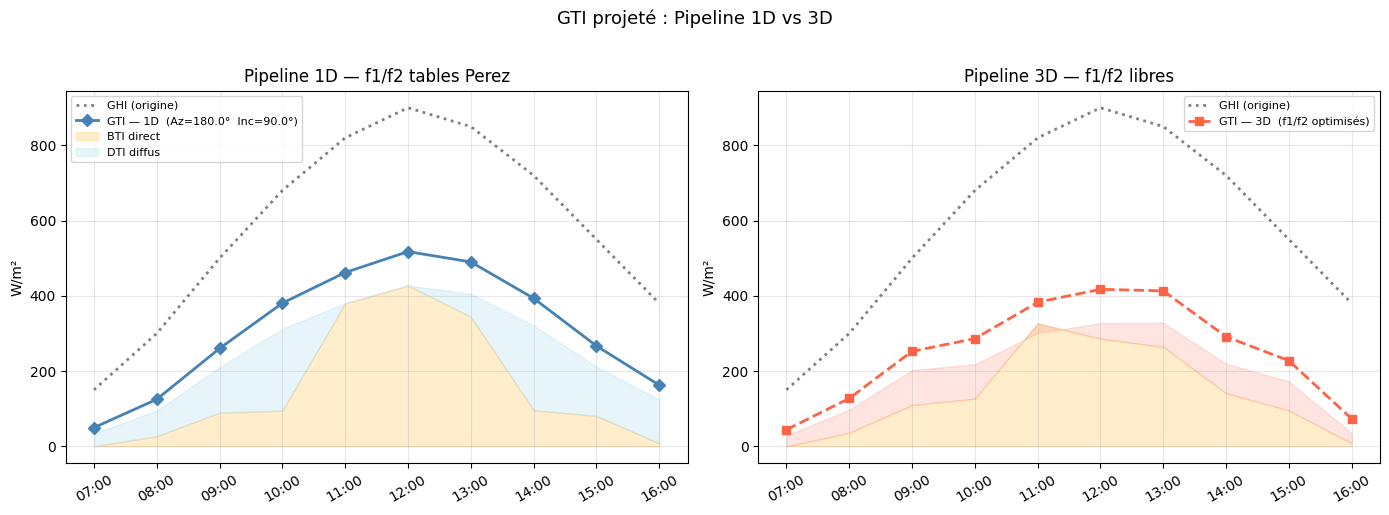

Exporté : results_1d.csv, results_3d.csv


In [13]:
# ── GTI projeté : 1D vs 3D ────────────────────────────────────────────────────
x = np.arange(len(time_history))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ghi_vals = [atm.GHI[0] for atm in atm_1d_list]

ax = axes[0]
ax.plot(x, ghi_vals, color='gray', linestyle=':', lw=2, label='GHI (origine)')
ax.plot(x, df_final_1d['GTI'].values, marker='D', color='steelblue', lw=2,
        label=f'GTI — 1D  (Az={target_facade.info.azimuth_deg}°  Inc={target_facade.info.inclination_deg}°)')
ax.fill_between(x, df_final_1d['BTI'].values, alpha=0.2, color='orange', label='BTI direct')
ax.fill_between(x, df_final_1d['BTI'].values,
                df_final_1d['BTI'].values + df_final_1d['DTI'].values,
                alpha=0.2, color='skyblue', label='DTI diffus')
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_ylabel('W/m²'); ax.set_title('Pipeline 1D — f1/f2 tables Perez')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(x, ghi_vals, color='gray', linestyle=':', lw=2, label='GHI (origine)')
ax.plot(x, df_final_3d['GTI'].values, marker='s', color='tomato', lw=2,
        linestyle='--', label='GTI — 3D  (f1/f2 optimisés)')
ax.fill_between(x, df_final_3d['BTI'].values, alpha=0.2, color='orange')
ax.fill_between(x, df_final_3d['BTI'].values,
                df_final_3d['BTI'].values + df_final_3d['DTI'].values,
                alpha=0.2, color='salmon')
ax.set_xticks(x); ax.set_xticklabels(time_history, rotation=30)
ax.set_ylabel('W/m²'); ax.set_title('Pipeline 3D — f1/f2 libres')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.suptitle('GTI projeté : Pipeline 1D vs 3D', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Export
df_final_1d.to_csv(ROOT / 'data' / 'results_1d.csv', index=False)
df_final_3d.to_csv(ROOT / 'data' / 'results_3d.csv', index=False)
print("Exporté : results_1d.csv, results_3d.csv")
